# 1. Carga de datos

En esta sección se cargan los datasets principales del análisis:

- **RAW_DATA:** métricas operacionales (órdenes, RT, earnings, clima)
- **ZONE_INFO:** metadata de zonas

In [65]:
# ===================================================
# 1. LOAD DATA
# ===================================================

# ---------------------------------------------------
# Importar librerías
# ---------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

# configuración visual consistente
sns.set(style="whitegrid")


# ---------------------------------------------------
# Cargar dataset desde archivo local
# ---------------------------------------------------
file_path = "../data/raw/rappi_delivery_case_data.xlsx"

# leer hojas del Excel
df = pd.read_excel(file_path, sheet_name="RAW_DATA")
zone_info = pd.read_excel(file_path, sheet_name="ZONE_INFO")


# ---------------------------------------------------
# revisión inicial
# ---------------------------------------------------
# verificar dimensiones
print("Shape dataset:", df.shape)

# preview inicial
df.head()

Shape dataset: (10081, 9)


,COUNTRY,DATE,HOUR,CITY,ZONE,CONNECTED_RT,ORDERS,EARNINGS,PRECIPITATION_MM
0,Mexico,2024-03-01,0,Monterrey,Centro,6,2,54.4,0.0
1,Mexico,2024-03-01,0,Monterrey,Mitras Centro,5,1,52.4,0.0
2,Mexico,2024-03-01,0,Monterrey,Apodaca Centro,4,1,59.1,0.0
3,Mexico,2024-03-01,0,Monterrey,Escobedo,3,1,53.3,0.0
4,Mexico,2024-03-01,0,Monterrey,Carretera Nacional,2,0,55.0,0.0


# 2. Validación de calidad de datos

Antes del análisis, se valida la calidad del dataset para evitar sesgos o errores:

- Tipos de datos
- Valores nulos
- Duplicados
- Validaciones de negocio (valores negativos, divisiones por cero)
- Consistencia en variables categóricas

In [86]:
# ===================================================
# 2. DATA QUALITY CHECKS
# ===================================================

# ---------------------------------------------------
# Tipos de datos
# ---------------------------------------------------
print("Tipos de datos:\n")
print(df.dtypes)


# ---------------------------------------------------
# Valores nulos
# ---------------------------------------------------
print("\nValores nulos por columna:\n")
print(df.isnull().sum())


# ---------------------------------------------------
# Duplicados
# ---------------------------------------------------
duplicates = df.duplicated().sum()
print(f"\nFilas duplicadas: {duplicates}")


# ===================================================
# VALIDACIONES DE NEGOCIO
# ===================================================

# ---------------------------------------------------
# Órdenes negativas
# ---------------------------------------------------
orders_negative = (df["ORDERS"] < 0).sum()
print(f"Orders negativos: {orders_negative}")


# ---------------------------------------------------
# RT negativos
# ---------------------------------------------------
rt_negative = (df["CONNECTED_RT"] < 0).sum()
print(f"RT negativos: {rt_negative}")


# ---------------------------------------------------
# RT en cero
# ---------------------------------------------------
rt_zero = (df["CONNECTED_RT"] == 0).sum()
print(f"RT igual a 0: {rt_zero}")


# ===================================================
# LIMPIEZA DE CATEGÓRICAS
# ===================================================

# ---------------------------------------------------
# COUNTRY
# ---------------------------------------------------
df["COUNTRY"] = df["COUNTRY"].str.upper().str.strip()


# ---------------------------------------------------
# CITY
# ---------------------------------------------------
df["CITY"] = df["CITY"].str.title().str.strip()


# ---------------------------------------------------
# Validación posterior
# ---------------------------------------------------
print("\nCOUNTRY únicos:", df["COUNTRY"].unique())
print("CITY únicos:", df["CITY"].unique())


# ===================================================
# VALIDACIONES ESTRUCTURALES
# ===================================================

# ---------------------------------------------------
# Zonas
# ---------------------------------------------------
print("\nNúmero de zonas:", df["ZONE"].nunique())
print("Zonas:", df["ZONE"].unique())


# ---------------------------------------------------
# Horas
# ---------------------------------------------------
print("\nHoras únicas:", sorted(df["HOUR"].unique()))


# ===================================================
# VALIDACIÓN DE FECHAS
# ===================================================

# convertir a datetime
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# contar inválidos
invalid_dates = df["DATE"].isnull().sum()
print(f"\nFechas inválidas: {invalid_dates}")

Tipos de datos:

COUNTRY              object
DATE                 object
HOUR                  int64
CITY                 object
ZONE                 object
CONNECTED_RT          int64
ORDERS                int64
EARNINGS            float64
PRECIPITATION_MM    float64
RATIO               float64
STATE                object
dtype: object

Valores nulos por columna:

COUNTRY             0
DATE                0
HOUR                0
CITY                0
ZONE                0
CONNECTED_RT        0
ORDERS              0
EARNINGS            0
PRECIPITATION_MM    0
RATIO               0
STATE               0
dtype: int64

Filas duplicadas: 0
Orders negativos: 0
RT negativos: 0
RT igual a 0: 0

COUNTRY únicos: ['MEXICO']
CITY únicos: ['Monterrey' 'Cali']

Número de zonas: 15
Zonas: ['Centro' 'Mitras Centro' 'Apodaca Centro' 'Escobedo' 'Carretera Nacional'
 'MTY_Apodaca_Huinalá' 'San Nicolás' 'Santa Catarina' 'San Pedro'
 'Cumbres Poniente' 'La Fe' 'MTY_Guadalupe' 'Independencia' 'Santiago'
 '

# 3. Feature Engineering

Se construye la métrica principal del análisis:

**Ratio = Órdenes / RT conectados**

Esta variable permite identificar:

- Sobre-oferta (< 0.5)
- Balance saludable (0.9 – 1.2)
- Saturación (> 1.8)

In [87]:
# ===================================================
# 3. FEATURE ENGINEERING
# ===================================================

# ---------------------------------------------------
# Crear ratio operacional
# ---------------------------------------------------
# evitar división por cero reemplazando RT=0 por NaN
df["RATIO"] = df["ORDERS"] / df["CONNECTED_RT"].replace(0, np.nan)


# ---------------------------------------------------
# Validación rápida
# ---------------------------------------------------
df[["ORDERS", "CONNECTED_RT", "RATIO", "PRECIPITATION_MM"]].describe()

,ORDERS,CONNECTED_RT,RATIO,PRECIPITATION_MM
count,10081.000000,10081.000000,10081.000000,10081.000000
mean,9.439341,9.141851,0.817843,0.246642
std,10.611703,7.650171,0.550972,1.264986
min,0.000000,1.000000,0.000000,0.000000
25%,1.000000,3.000000,0.500000,0.000000
50%,6.000000,7.000000,0.800000,0.000000
75%,14.000000,13.000000,1.096774,0.000000
max,57.000000,46.000000,5.666667,10.300000


# 📊 4. Exploratory Data Analysis (EDA)

Se analiza la distribución de las principales variables operacionales:

- Órdenes
- Repartidores conectados (RT)
- Ratio operacional
- Precipitación

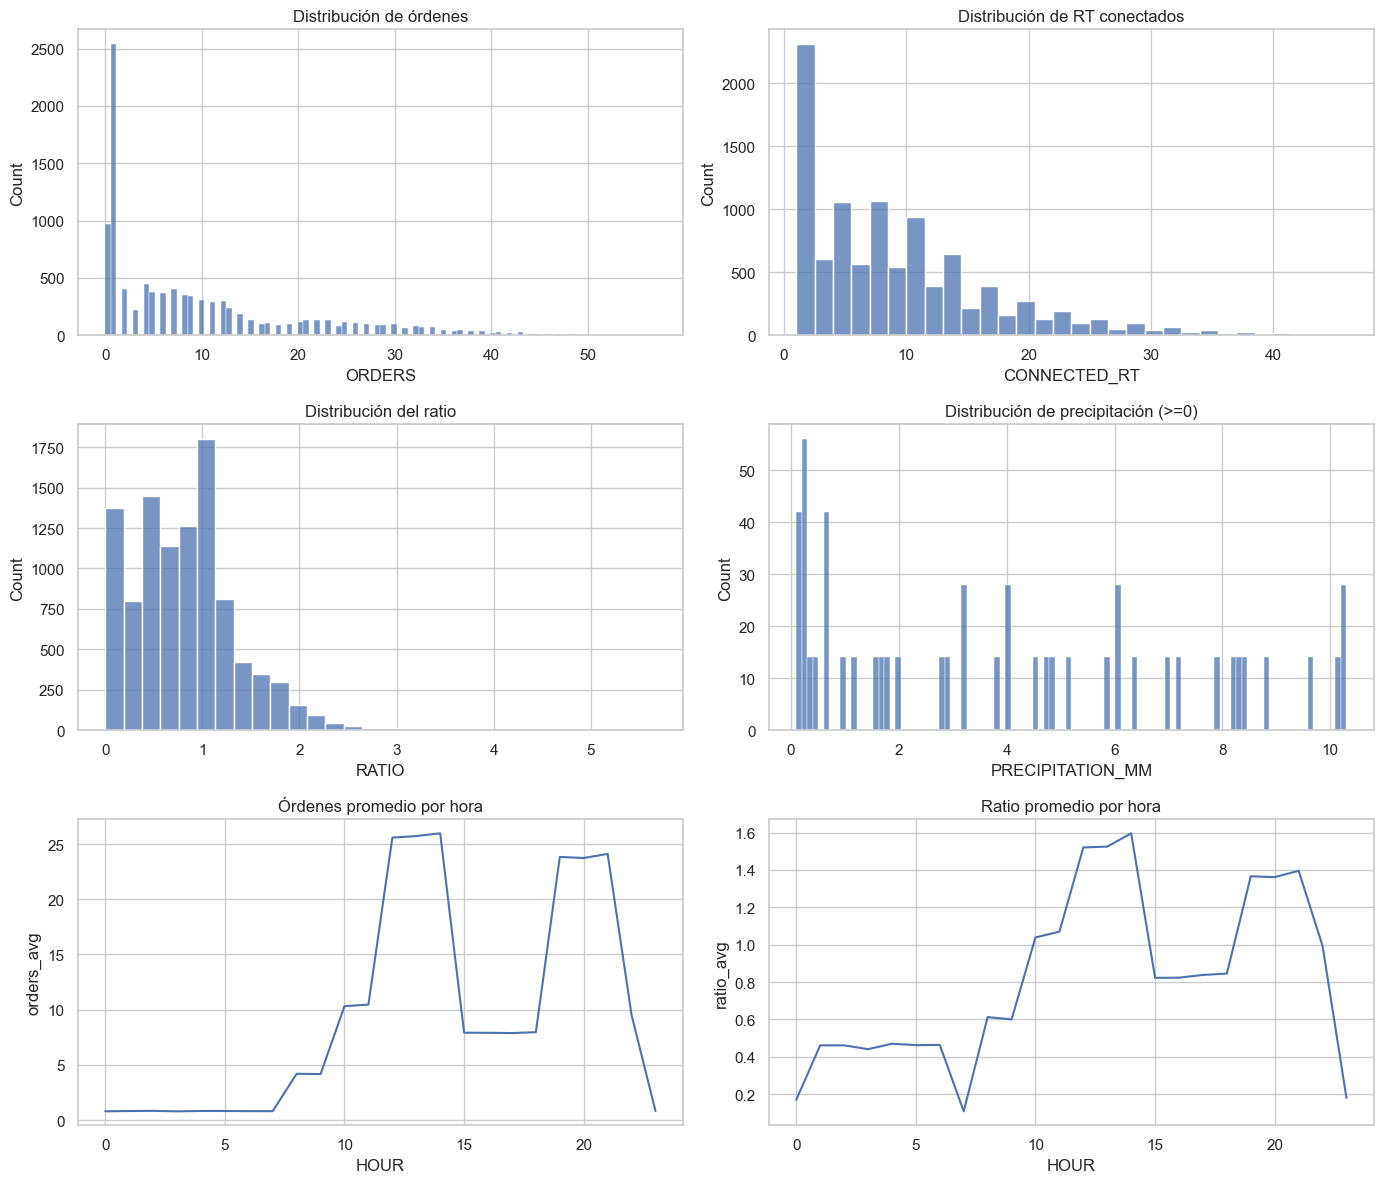

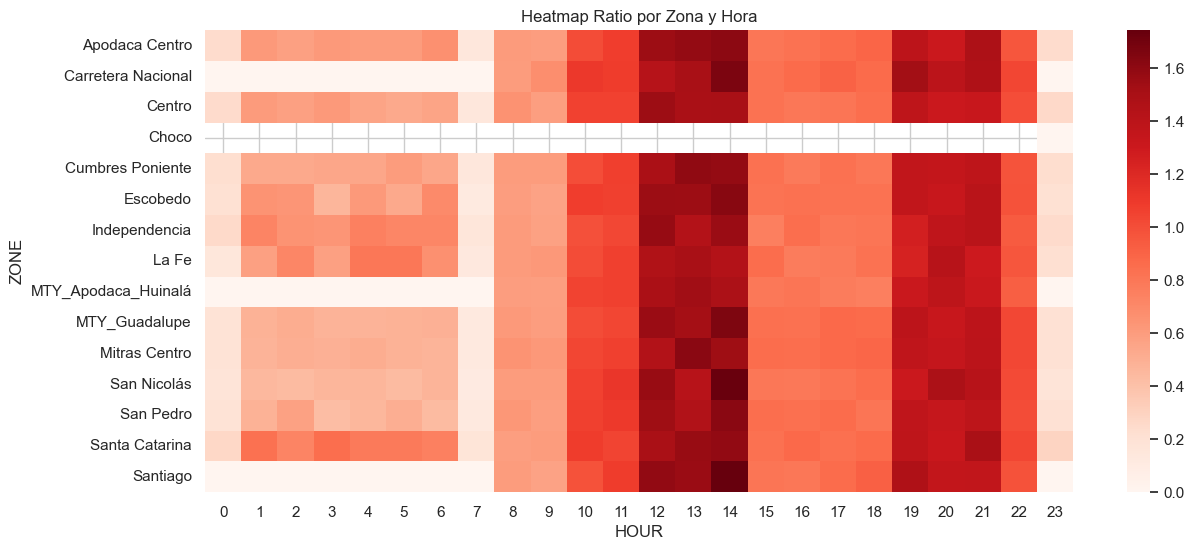

In [67]:
# ===================================================
# 4. EDA
# ===================================================

# ---------------------------------------------------
# Preparar aregados por hora
# ---------------------------------------------------
hourly = df.groupby("HOUR").agg(
    orders_avg=("ORDERS", "mean"),
    ratio_avg=("RATIO", "mean")
).reset_index()


# ---------------------------------------------------
# Crear figura principal
# ---------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(14, 12))


# ===================================================
# DISTRIBUCIONES
# ===================================================

# Órdenes
sns.histplot(df["ORDERS"], bins=100, ax=axes[0, 0])
axes[0, 0].set_title("Distribución de órdenes")

# RT
sns.histplot(df["CONNECTED_RT"], bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Distribución de RT conectados")

# Ratio
sns.histplot(df["RATIO"], bins=30, ax=axes[1, 0])
axes[1, 0].set_title("Distribución del ratio")

# Precipitación > 0
sns.histplot(
    df[df["PRECIPITATION_MM"] > 0]["PRECIPITATION_MM"],
    bins=100,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Distribución de precipitación (>=0)")


# ===================================================
# SERIES TEMPORALES
# ===================================================

# Órdenes por hora
sns.lineplot(data=hourly, x="HOUR", y="orders_avg", ax=axes[2, 0])
axes[2, 0].set_title("Órdenes promedio por hora")

# Ratio por hora
sns.lineplot(data=hourly, x="HOUR", y="ratio_avg", ax=axes[2, 1])
axes[2, 1].set_title("Ratio promedio por hora")


# ---------------------------------------------------
# Ajuste visual
# ---------------------------------------------------
plt.tight_layout()
plt.show()


# ===================================================
# HEATMAP (ZONA vs HORA)
# ===================================================

# ---------------------------------------------------
# Agregación zona-hora
# ---------------------------------------------------
agg_zone_hour = df.groupby(["ZONE", "HOUR"]).agg(
    ratio_avg=("RATIO", "mean")
).reset_index()

# pivot para heatmap
pivot_ratio = agg_zone_hour.pivot(
    index="ZONE",
    columns="HOUR",
    values="ratio_avg"
)


# ---------------------------------------------------
# Visualización
# ---------------------------------------------------
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_ratio, cmap="Reds")

plt.title("Heatmap Ratio por Zona y Hora")

plt.show()

# P1 — Saturación y sobre-oferta por zona y hora

El objetivo de esta sección es identificar:

- En qué **horas del día**
- En qué **zonas**

la operación alcanza estados críticos de:

- **Saturación** (ratio > 1.8)
- **Sobre-oferta** (ratio < 0.5)

In [68]:
# ===================================================
# 5. P1 - SATURACIÓN Y SOBRE-OFERTA
# ===================================================

# ---------------------------------------------------
# Definir thresholds de negocio
# ---------------------------------------------------
SATURATION_THRESHOLD = 1.8
OVERSUPPLY_THRESHOLD = 0.5


# ---------------------------------------------------
# Clasificar estado operacional
# ---------------------------------------------------
def classify_state(ratio):
    # asigna categoría según thresholds
    if ratio > SATURATION_THRESHOLD:
        return "saturation"
    elif ratio < OVERSUPPLY_THRESHOLD:
        return "oversupply"
    else:
        return "healthy"


# aplicar clasificación
df["STATE"] = df["RATIO"].apply(classify_state)


# ---------------------------------------------------
# Construir tabla zona-hora
# ---------------------------------------------------
p1_zone_hour = df.groupby(["ZONE", "HOUR"]).agg(
    ratio_avg=("RATIO", "mean"),
    ratio_p95=("RATIO", lambda x: x.quantile(0.95)),
    saturation_events=("STATE", lambda x: (x == "saturation").sum()),
    oversupply_events=("STATE", lambda x: (x == "oversupply").sum()),
    total_obs=("STATE", "count")
).reset_index()


# ---------------------------------------------------
# Calcular tasas
# ---------------------------------------------------
p1_zone_hour["saturation_rate"] = (
    p1_zone_hour["saturation_events"] / p1_zone_hour["total_obs"]
)

p1_zone_hour["oversupply_rate"] = (
    p1_zone_hour["oversupply_events"] / p1_zone_hour["total_obs"]
)


# ---------------------------------------------------
# Guardar outputs
# ---------------------------------------------------
p1_zone_hour.to_csv(
    "../modulo1_diagnostico/outputs/tables/p1_ratio_zone_hour.csv",
    index=False
)

p1_zone_hour.to_excel(
    "../modulo1_diagnostico/outputs/tables/p1_ratio_zone_hour.xlsx",
    index=False
)

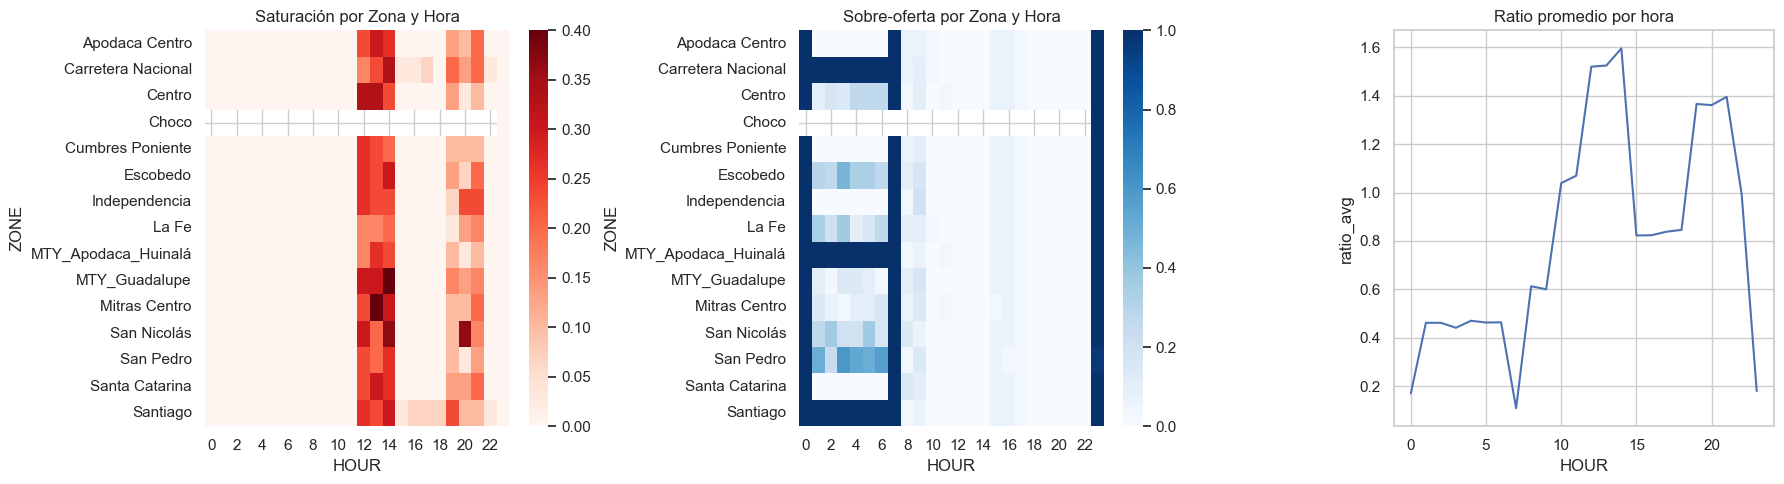

In [69]:
# ===================================================
# VISUALIZACIONES P1
# ===================================================

# ---------------------------------------------------
# Crear pivots
# ---------------------------------------------------
pivot_sat = p1_zone_hour.pivot(
    index="ZONE",
    columns="HOUR",
    values="saturation_rate"
)

pivot_over = p1_zone_hour.pivot(
    index="ZONE",
    columns="HOUR",
    values="oversupply_rate"
)


# ---------------------------------------------------
# Dashboard combinado
# ---------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# saturación
sns.heatmap(pivot_sat, cmap="Reds", ax=axes[0])
axes[0].set_title("Saturación por Zona y Hora")

# sobreoferta
sns.heatmap(pivot_over, cmap="Blues", ax=axes[1])
axes[1].set_title("Sobre-oferta por Zona y Hora")

# ratio por hora
sns.lineplot(data=hourly, x="HOUR", y="ratio_avg", ax=axes[2])
axes[2].set_title("Ratio promedio por hora")

plt.tight_layout()

# guardar
plt.savefig("../modulo1_diagnostico/outputs/figures/p1_dashboard.png")

plt.show()

In [70]:
# ===================================================
# ANÁLISIS DETALLADO
# ===================================================

# ---------------------------------------------------
# Madrugada (0-7)
# ---------------------------------------------------
overnight = p1_zone_hour[p1_zone_hour["HOUR"].between(0, 7)]

overnight_stats = overnight.groupby("HOUR").agg(
    avg_oversupply=("oversupply_rate", "mean"),
    avg_ratio=("ratio_avg", "mean")
).reset_index()

print("Madrugada:")
print(overnight_stats)
print("Promedio sobre-oferta:", overnight["oversupply_rate"].mean())


# ---------------------------------------------------
# Mediodía (12-14)
# ---------------------------------------------------
peak_hours = p1_zone_hour[p1_zone_hour["HOUR"].between(12, 14)]

peak_stats = peak_hours.groupby("HOUR").agg(
    avg_ratio=("ratio_avg", "mean"),
    avg_saturation=("saturation_rate", "mean")
).reset_index()

print("\nMediodía:")
print(peak_stats)
print("Promedio saturación:", peak_hours["saturation_rate"].mean())


# ---------------------------------------------------
# Noche (18-22)
# ---------------------------------------------------
evening_hours = p1_zone_hour[p1_zone_hour["HOUR"].between(18, 22)]

evening_stats = evening_hours.groupby("HOUR").agg(
    avg_ratio=("ratio_avg", "mean"),
    avg_saturation=("saturation_rate", "mean")
).reset_index()

print("\nNoche:")
print(evening_stats)
print("Promedio saturación:", evening_hours["saturation_rate"].mean())


# ---------------------------------------------------
# Crear variable de franja horaria
# ---------------------------------------------------
def assign_time_block(hour):
    # segmentación basada en comportamiento operacional
    if 0 <= hour <= 7:
        return "overnight"
    elif 12 <= hour <= 14:
        return "midday"
    elif 18 <= hour <= 22:
        return "evening"
    else:
        return "other"


# aplicar clasificación
p1_zone_hour["time_block"] = p1_zone_hour["HOUR"].apply(assign_time_block)


# ---------------------------------------------------
# Filtrar solo franjas relevantes
# ---------------------------------------------------
critical_blocks = ["overnight", "midday", "evening"]

p1_filtered = p1_zone_hour[
    p1_zone_hour["time_block"].isin(critical_blocks)
]


# ---------------------------------------------------
# Calcular criticidad por zona y franja
# ---------------------------------------------------
zone_criticality = p1_filtered.groupby(
    ["ZONE", "time_block"]
).agg(
    avg_saturation=("saturation_rate", "mean"),
    avg_oversupply=("oversupply_rate", "mean"),
    avg_ratio=("ratio_avg", "mean")
).reset_index()

# ---------------------------------------------------
# Seleccionar top 5
# ---------------------------------------------------
top5_by_block = (
    zone_criticality
    .sort_values(["time_block", "avg_saturation"], ascending=[True, False])
    .groupby("time_block")
    .head(5)
    .reset_index(drop=True)
)

top5_by_block

Madrugada:
   HOUR  avg_oversupply  avg_ratio
0     0        1.000000   0.170051
1     1        0.338095   0.461508
2     2        0.309524   0.461508
3     3        0.352381   0.441071
4     4        0.333333   0.470040
5     5        0.345238   0.462698
6     6        0.338095   0.463492
7     7        1.000000   0.108225
Promedio sobre-oferta: 0.5020833333333333

Mediodía:
   HOUR  avg_ratio  avg_saturation
0    12   1.520648        0.245238
1    13   1.525285        0.259524
2    14   1.596144        0.278571
Promedio saturación: 0.2611111111111111

Noche:
   HOUR  avg_ratio  avg_saturation
0    18   0.845851        0.004762
1    19   1.366347        0.123810
2    20   1.361651        0.121429
3    21   1.395798        0.161905
4    22   0.993293        0.004762
Promedio saturación: 0.08333333333333331


,ZONE,time_block,avg_saturation,avg_oversupply,avg_ratio
0,San Nicolás,evening,0.126667,0.000000,1.217628
1,Carretera Nacional,evening,0.113333,0.000000,1.259084
2,Independencia,evening,0.106667,0.000000,1.159021
3,Santiago,evening,0.106667,0.000000,1.216106
4,MTY_Guadalupe,evening,0.093333,0.000000,1.202547
5,MTY_Guadalupe,midday,0.333333,0.000000,1.581493
6,Mitras Centro,midday,0.311111,0.000000,1.535697
7,Centro,midday,0.300000,0.000000,1.513601
8,San Nicolás,midday,0.288889,0.000000,1.574447
9,Apodaca Centro,midday,0.266667,0.000000,1.578953


## P1 — Saturación por hora y zona

La operación alcanza niveles críticos principalmente en dos momentos del día:

### Mediodía (12:00 – 14:00) — Pico principal

- Ratio promedio: 1.52 – 1.60  
- Saturación promedio: 26.1%  
- Aproximadamente 1 de cada 4 horas está en saturación  

Zonas más afectadas:
- MTY_Guadalupe → 33.3%  
- Mitras Centro → 31.1%  
- Centro → 30.0%  
- San Nicolás → 28.9%  
- Apodaca Centro → 26.7%  

Es el momento más crítico del día.

---

### Noche (19:00 – 21:00) — Segundo pico

- Ratio promedio: 1.36 – 1.39  
- Saturación promedio: 8.3%  
- Aproximadamente 1 de cada 12 horas está en saturación  

Zonas más afectadas:
- San Nicolás → 12.7%  
- Carretera Nacional → 11.3%  
- Independencia → 10.7%  
- Santiago → 10.7%  
- MTY_Guadalupe → 9.3%  

---

### Madrugada (0:00 – 7:00)

- No hay saturación relevante  
- Predomina sobre-oferta (hasta 50% en promedio)

---

# P2 — Impacto de la lluvia en el deterioro del ratio

El objetivo de esta sección es identificar qué variable externa del dataset está asociada con el deterioro del ratio operacional.

Se analiza la relación entre la precipitación y:

- Ratio operacional  
- Probabilidad de saturación  
- Balance entre oferta (RT) y demanda (órdenes)  

El enfoque combina:

- Relación lineal (correlación)
- Análisis por niveles de lluvia
- Cambios en la distribución de estados operacionales

Correlación lluvia vs ratio: 0.319


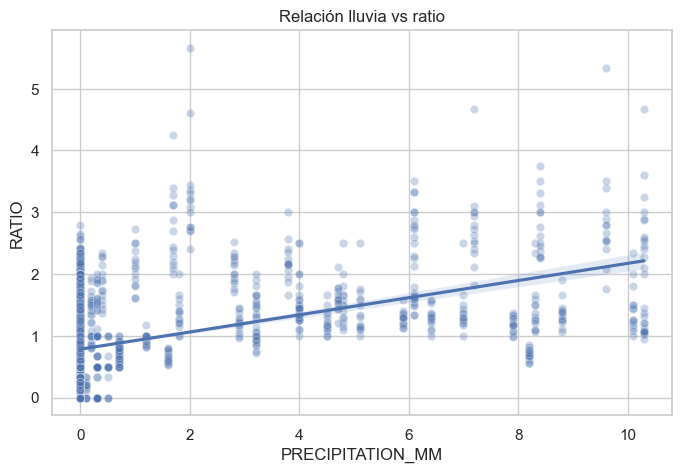

In [21]:
# ===================================================
# 6. P2 - Impacto de lluvia
# ===================================================


# ---------------------------------------------------
# Crear copia de trabajo
# ---------------------------------------------------
df_p2 = df.copy()


# ---------------------------------------------------
# Variables binarias de estado
# ---------------------------------------------------
df_p2["IS_SATURATED"] = (df_p2["STATE"] == "saturation").astype(int)
df_p2["IS_OVERSUPPLY"] = (df_p2["STATE"] == "oversupply").astype(int)

# ---------------------------------------------------
# Correlación simple
# ---------------------------------------------------
corr = df_p2["PRECIPITATION_MM"].corr(df_p2["RATIO"])
print(f"Correlación lluvia vs ratio: {corr:.3f}")


# ---------------------------------------------------
# Visualización scatter
# ---------------------------------------------------
plt.figure(figsize=(8, 5))

# nube de puntos
sns.scatterplot(
    data=df_p2,
    x="PRECIPITATION_MM",
    y="RATIO",
    alpha=0.3
)

# tendencia promedio
sns.regplot(
    data=df_p2,
    x="PRECIPITATION_MM",
    y="RATIO",
    scatter=False
)

plt.title("Relación lluvia vs ratio")

plt.savefig("../modulo1_diagnostico/outputs/figures/p2_scatter_ratio.png")

plt.show()

In [23]:
# ===================================================
# DEFINICIÓN DE NIVELES DE LLUVIA
# ===================================================

# ---------------------------------------------------
# Revisar percentiles (solo lluvia > 0)
# ---------------------------------------------------
rain_positive = df_p2[df_p2["PRECIPITATION_MM"] > 0]

print(
    rain_positive["PRECIPITATION_MM"]
    .quantile([0.5, 0.75, 0.9, 0.95])
)


# ---------------------------------------------------
# Crear niveles de lluvia (bins manuales)
# ---------------------------------------------------
df_p2["rain_level"] = pd.cut(
    df_p2["PRECIPITATION_MM"],
    bins=[-0.01, 0.01, 3.5, 6.5, 10.5],
    labels=["no_rain", "moderate", "heavy", "extreme"]
)


# ---------------------------------------------------
# Validación
# ---------------------------------------------------
print(df_p2["rain_level"].value_counts())

0.50     3.50
0.75     6.55
0.90     8.80
0.95    10.10
Name: PRECIPITATION_MM, dtype: float64
rain_level
no_rain     9464
moderate     308
heavy        154
extreme      154
Name: count, dtype: int64


In [24]:
# ===================================================
# IMPACTO DE LLUVIA EN LA OPERACIÓN
# ===================================================

# ---------------------------------------------------
# Agregación por nivel de lluvia
# ---------------------------------------------------
rain_impact = df_p2.groupby("rain_level").agg(
    saturation_rate=("IS_SATURATED", "mean"),
    oversupply_rate=("IS_OVERSUPPLY", "mean"),
    avg_ratio=("RATIO", "mean"),
    avg_rts=("CONNECTED_RT", "mean"),
    avg_orders=("ORDERS", "mean"),
    count=("RATIO", "count")
).reset_index()


# ---------------------------------------------------
# Orden lógico de categorías
# ---------------------------------------------------
order = ["no_rain", "moderate", "heavy", "extreme"]

rain_impact = (
    rain_impact
    .set_index("rain_level")
    .loc[order]
    .reset_index()
)


# ---------------------------------------------------
# Guardar output
# ---------------------------------------------------
rain_impact.to_csv(
    "../modulo1_diagnostico/outputs/tables/p2_rain_impact.csv",
    index=False
)

rain_impact

C:\Users\isaac.sanchez\AppData\Local\Temp\ipykernel_1240\1383595499.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rain_impact = df_p2.groupby("rain_level").agg(


,rain_level,saturation_rate,oversupply_rate,avg_ratio,avg_rts,avg_orders,count
0,no_rain,0.036771,0.235207,0.774945,8.940406,8.867498,9464
1,moderate,0.224026,0.100649,1.233486,10.652597,14.905844,308
2,heavy,0.227273,0.000000,1.633909,13.129870,20.597403,154
3,extreme,0.396104,0.000000,1.812083,14.558442,22.551948,154


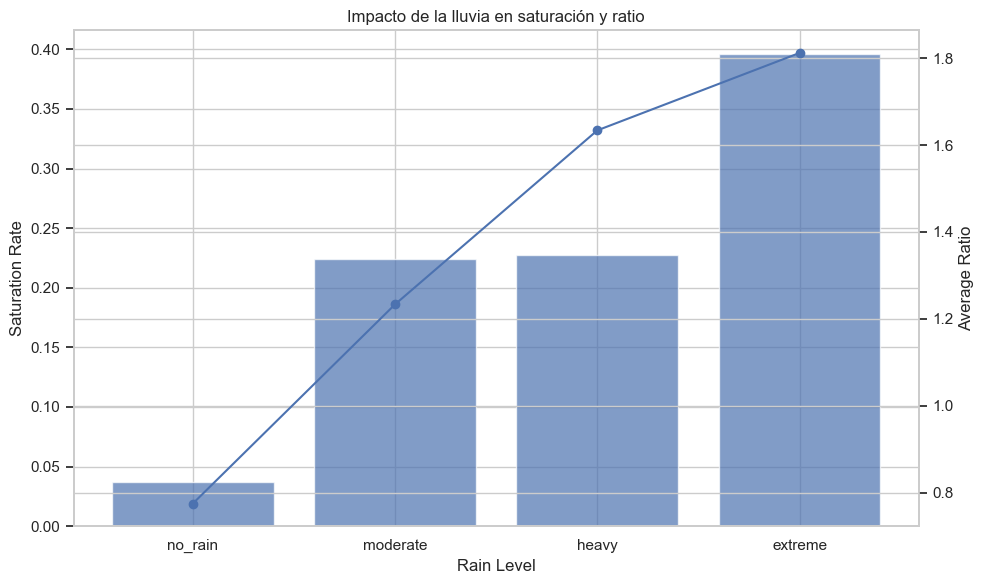

C:\Users\isaac.sanchez\AppData\Local\Temp\ipykernel_1240\4179615078.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["rain_level", "STATE"])


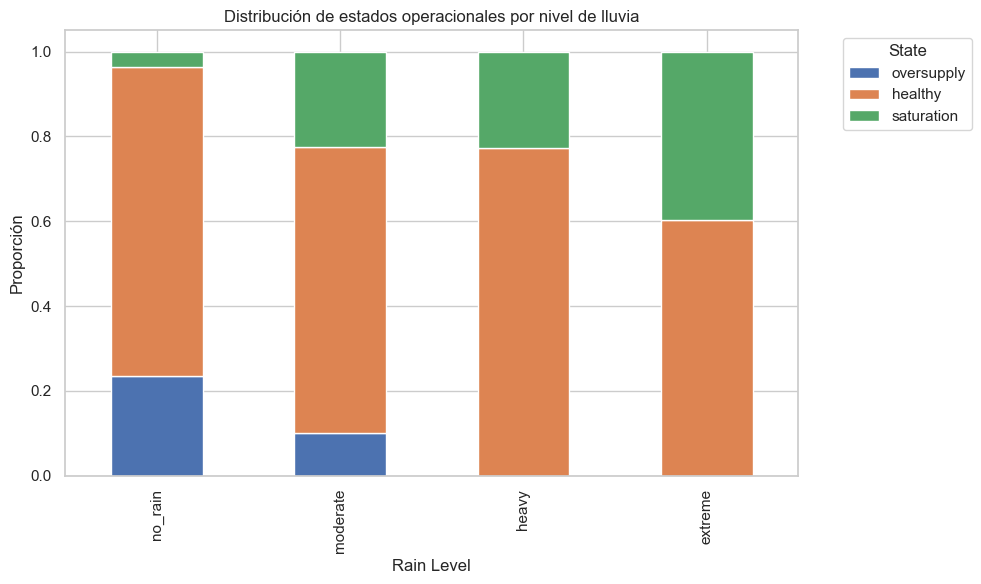

In [71]:
# ===================================================
# VISUALIZACIÓN PRINCIPAL
# ===================================================

fig, ax1 = plt.subplots(figsize=(10, 6))

# ---------------------------------------------------
# Barras: saturación
# ---------------------------------------------------
ax1.bar(
    rain_impact["rain_level"],
    rain_impact["saturation_rate"],
    alpha=0.7
)
ax1.set_ylabel("Saturation Rate")
ax1.set_xlabel("Rain Level")


# ---------------------------------------------------
# Línea: ratio
# ---------------------------------------------------
ax2 = ax1.twinx()

ax2.plot(
    rain_impact["rain_level"],
    rain_impact["avg_ratio"],
    marker="o"
)
ax2.set_ylabel("Average Ratio")

plt.title("Impacto de la lluvia en saturación y ratio")

plt.tight_layout()

plt.savefig("../modulo1_diagnostico/outputs/figures/p2_saturation_ratio.png")

plt.show()
plt.close()


# ---------------------------------------------------
# Conteo de estados
# ---------------------------------------------------
state_dist = (
    df_p2
    .groupby(["rain_level", "STATE"])
    .size()
    .unstack(fill_value=0)
)

# ---------------------------------------------------
# Convertir a proporciones
# ---------------------------------------------------
state_dist = state_dist.div(state_dist.sum(axis=1), axis=0)

# ordenar niveles de lluvia
state_dist = state_dist.loc[order]

# ordenar estados
state_order = ["oversupply", "healthy", "saturation"]
state_dist = state_dist[state_order]


# ---------------------------------------------------
# Visualización
# ---------------------------------------------------
ax = state_dist.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribución de estados operacionales por nivel de lluvia")
plt.ylabel("Proporción")
plt.xlabel("Rain Level")

plt.legend(title="State", bbox_to_anchor=(1.05, 1))

plt.tight_layout()

plt.savefig("../modulo1_diagnostico/outputs/figures/p2_state_distribution.png")

plt.show()
plt.close()

## P2 — Impacto de la lluvia en el deterioro operacional

Se observa una **relación lineal positiva moderada** entre la precipitación y el ratio, con un coeficiente de **0.319**. Es decir, a medida que **aumenta la precipitación**, el **ratio tiende a incrementarse**


### Comportamiento observado

- Sin lluvia:
  - Saturación: 3.7%
  - Ratio: 0.77

- Lluvia moderada:
  - Saturación: 22.4%
  - Ratio: 1.23

- Lluvia fuerte:
  - Saturación: 22.7%
  - Ratio: 1.63

- Lluvia extrema:
  - Saturación: 39.6%
  - Ratio: 1.81

La probabilidad de saturación aumenta más de 10 veces entre condiciones sin lluvia y lluvia extrema.

- Las órdenes aumentan significativamente con la lluvia (~+155%)
- Los repartidores también aumentan, pero menos (~+63%)

Esto genera un desbalance donde la demanda crece más rápido que la oferta.

### Conclusión

La lluvia está directamente asociada con el deterioro del ratio y el aumento de la saturación, especialmente a partir de niveles altos de precipitación.

# P3 — ¿Todas las zonas responden igual a la lluvia?

El objetivo es evaluar si el impacto de la lluvia sobre la operación es homogéneo o si existen diferencias relevantes entre zonas.

Para esto se compara el comportamiento de cada zona en dos escenarios:

- Sin lluvia  
- Con lluvia  

Se analiza:

- Cambio en la probabilidad de saturación  
- Cambios en ratio  
- Diferencias en el crecimiento de órdenes y repartidores  

In [32]:
# ===================================================
# 7. P3 - RESPUESTA A LLUVIA POR ZONA
# ===================================================

# ---------------------------------------------------
# Copia de trabajo
# ---------------------------------------------------
df_p3 = df.copy()


# ---------------------------------------------------
# Variable binaria de lluvia
# ---------------------------------------------------
# simplifica el análisis: lluvia vs no lluvia
df_p3["rain_binary"] = np.where(
    df_p3["PRECIPITATION_MM"] > 0,
    "rain",
    "no_rain"
)

In [73]:
# ===================================================
# SENSIBILIDAD A LA LLUVIA POR ZONA
# ===================================================

# ---------------------------------------------------
# Métricas por zona y condición
# ---------------------------------------------------
df_p3["IS_SATURATED"] = df_p3["RATIO"] >= 1.8
zone_binary = df_p3.groupby(["ZONE", "rain_binary"]).agg(
    saturation_rate=("IS_SATURATED", "mean"),
    avg_ratio=("RATIO", "mean"),
    count=("RATIO", "count")
).reset_index()


# ---------------------------------------------------
# Pivot para comparar lluvia vs no lluvia
# ---------------------------------------------------
zone_pivot = zone_binary.pivot(
    index="ZONE",
    columns="rain_binary",
    values="saturation_rate"
).reset_index()


# ---------------------------------------------------
# Calcular sensibilidad
# ---------------------------------------------------
# cuánto aumenta la saturación cuando llueve
zone_pivot["sensitivity"] = (
    zone_pivot["rain"] - zone_pivot["no_rain"]
)


# ---------------------------------------------------
# Ordenar de mayor a menor impacto
# ---------------------------------------------------
zone_pivot = zone_pivot.sort_values(
    "sensitivity",
    ascending=False
)

zone_pivot

rain_binary,ZONE,no_rain,rain,sensitivity
13,Santiago,0.036982,0.454545,0.417563
1,Carretera Nacional,0.035503,0.431818,0.396315
12,Santa Catarina,0.039941,0.340909,0.300968
9,Mitras Centro,0.041420,0.272727,0.231307
4,Escobedo,0.044379,0.272727,0.228349
8,MTY_Guadalupe,0.050296,0.272727,0.222431
2,Centro,0.035503,0.250000,0.214497
5,Independencia,0.041420,0.250000,0.208580
11,San Pedro,0.029586,0.227273,0.197687
3,Cumbres Poniente,0.041420,0.227273,0.185853


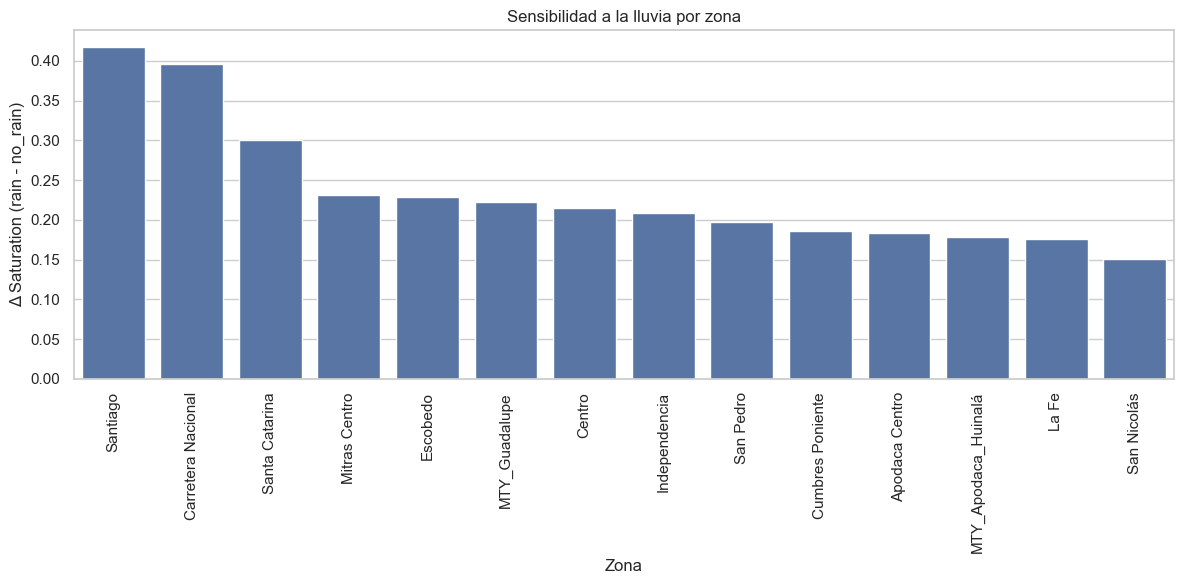

In [74]:
# ===================================================
# VISUALIZACIÓN SENSIBILIDAD
# ===================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=zone_pivot,
    x="ZONE",
    y="sensitivity"
)

plt.xticks(rotation=90)

plt.title("Sensibilidad a la lluvia por zona")
plt.ylabel("Δ Saturation (rain - no_rain)")
plt.xlabel("Zona")

plt.tight_layout()

plt.savefig("../modulo1_diagnostico/outputs/figures/p3_zone_sensitivity_binary.png")

plt.show()

In [88]:
# ===================================================
# RESUMEN OPERACIONAL
# ===================================================

# ---------------------------------------------------
# Promedios por zona y condición
# ---------------------------------------------------
zone_mechanism = df_p3.groupby(["ZONE", "rain_binary"]).agg(
    avg_orders=("ORDERS", "mean"),
    avg_rts=("CONNECTED_RT", "mean")
).reset_index()


# ---------------------------------------------------
# Pivot para comparar crecimiento
# ---------------------------------------------------
zone_mech_pivot = zone_mechanism.pivot(
    index="ZONE",
    columns="rain_binary",
    values=["avg_orders", "avg_rts"]
)

# renombrar columnas para claridad
zone_mech_pivot.columns = [
    "orders_no_rain",
    "orders_rain",
    "rts_no_rain",
    "rts_rain"
]

zone_mech_pivot = zone_mech_pivot.reset_index()


# ---------------------------------------------------
# Crecimientos relativos
# ---------------------------------------------------
zone_mech_pivot["orders_growth"] = (
    zone_mech_pivot["orders_rain"] /
    zone_mech_pivot["orders_no_rain"]
)

zone_mech_pivot["rts_growth"] = (
    zone_mech_pivot["rts_rain"] /
    zone_mech_pivot["rts_no_rain"]
)


# ---------------------------------------------------
# Desbalance (demanda - oferta)
# ---------------------------------------------------
zone_mech_pivot["imbalance"] = (
    zone_mech_pivot["orders_growth"] -
    zone_mech_pivot["rts_growth"]
)

zone_mech_pivot

,ZONE,orders_no_rain,orders_rain,rts_no_rain,rts_rain,orders_growth,rts_growth,imbalance
0,Apodaca Centro,9.053254,18.295455,8.923077,12.409091,2.020870,1.390674,0.630196
1,Carretera Nacional,5.474852,11.795455,5.649408,6.750000,2.154479,1.194815,0.959664
2,Centro,15.125740,31.159091,15.266272,21.295455,2.060004,1.394935,0.665070
3,Cumbres Poniente,9.384615,18.772727,9.415680,13.022727,2.000373,1.383089,0.617283
4,Escobedo,7.184911,14.909091,7.162722,10.000000,2.075056,1.396117,0.678938
5,Independencia,8.301775,17.136364,8.492604,11.500000,2.064181,1.354119,0.710061
6,La Fe,7.174556,14.840909,7.335799,10.386364,2.068547,1.415846,0.652701
7,MTY_Apodaca_Huinalá,4.205621,8.750000,4.588757,6.136364,2.080549,1.337260,0.743288
8,MTY_Guadalupe,10.705621,22.386364,10.646450,14.954545,2.091085,1.404651,0.686434
9,Mitras Centro,10.732249,21.636364,10.652367,15.181818,2.016014,1.425206,0.590808


## P3 — Diferencias por zona

No todas las zonas responden igual a la lluvia.

Se observa variabilidad en la sensibilidad, con incrementos en la saturación que van aproximadamente de 0.15 a 0.42.

### Zonas más sensibles

Zonas como Santiago y Carretera Nacional presentan los mayores aumentos en saturación.

### Qué está pasando en estas zonas

- Las órdenes crecen significativamente (hasta ~2x)
- Los repartidores crecen mucho menos (~1.1x – 1.2x)

Esto genera un desbalance fuerte entre demanda y oferta, aumentando el ratio y la saturación.

### Zonas menos sensibles

En zonas más estables, el crecimiento de repartidores acompaña mejor el aumento en órdenes, reduciendo el impacto en la operación.

### Conclusión

El impacto de la lluvia no es uniforme.

La sensibilidad depende de la capacidad de cada zona para ajustar su oferta frente al aumento de demanda, lo que implica que la operación debe gestionarse de forma segmentada.

# P4 — ¿El nivel de earnings está bien calibrado?

El objetivo es evaluar si los earnings responden correctamente a los cambios en la presión operacional.

Para esto se compara, por zona y hora:

- Nivel observado vs baseline histórico  
- Cambios en ratio vs cambios en earnings  

Se identifican dos tipos de problemas:

- Sub-reacción: el ratio sube pero los earnings no aumentan  
- Sobre-gasto: el ratio baja pero los earnings no disminuyen  

In [ ]:
# ===================================================
# 8. P4 - CALIBRACIÓN DE EARNINGS
# ===================================================

# ---------------------------------------------------
# Copia de trabajo
# ---------------------------------------------------
df_p4 = df.copy()

# asegurar formato datetime
df_p4["DATE"] = pd.to_datetime(df_p4["DATE"])

In [90]:
# ===================================================
# SERIES TEMPORALES POR ZONA
# ===================================================

# ---------------------------------------------------
# Agregación por zona, día y hora
# ---------------------------------------------------
ts_zone = df_p4.groupby(["ZONE", "DATE", "HOUR"]).agg(
    avg_ratio=("RATIO", "mean"),
    avg_earnings=("EARNINGS", "mean")
).reset_index()

In [91]:
# ===================================================
# BASELINE HISTÓRICO
# ===================================================

# ---------------------------------------------------
# Promedio esperado por zona y hora
# ---------------------------------------------------
baseline_zone_hour = df.groupby(["ZONE", "HOUR"]).agg(
    ratio_base=("RATIO", "mean"),
    earnings_base=("EARNINGS", "mean")
).reset_index()


# ---------------------------------------------------
# Merge con serie temporal
# ---------------------------------------------------
ts_zone = ts_zone.merge(
    baseline_zone_hour,
    on=["ZONE", "HOUR"],
    how="left"
)

In [92]:
# ===================================================
# DESVIACIONES Y CAMBIOS
# ===================================================

# ---------------------------------------------------
# Cambios respecto al tiempo anterior
# ---------------------------------------------------
ts_zone["ratio_diff"] = ts_zone.groupby("ZONE")["avg_ratio"].diff()
ts_zone["earnings_diff"] = ts_zone.groupby("ZONE")["avg_earnings"].diff()


# ---------------------------------------------------
# Desviación vs baseline
# ---------------------------------------------------
ts_zone["ratio_dev"] = ts_zone["avg_ratio"] - ts_zone["ratio_base"]
ts_zone["earnings_dev"] = ts_zone["avg_earnings"] - ts_zone["earnings_base"]

In [93]:
# ===================================================
# DEFINICIÓN DE UMBRALES
# ===================================================

# desviación típica como referencia de anomalía
ratio_tol = ts_zone["ratio_dev"].std()
earnings_tol = ts_zone["earnings_dev"].std()

In [94]:
# ===================================================
# CLASIFICACIÓN DE ESTADOS
# ===================================================

# ---------------------------------------------------
# Estado del ratio
# ---------------------------------------------------
ts_zone["ratio_state"] = "normal"

ts_zone.loc[ts_zone["ratio_dev"] > ratio_tol, "ratio_state"] = "high"
ts_zone.loc[ts_zone["ratio_dev"] < -ratio_tol, "ratio_state"] = "low"


# ---------------------------------------------------
# Estado de earnings
# ---------------------------------------------------
ts_zone["earnings_state"] = "normal"

ts_zone.loc[ts_zone["earnings_dev"] > earnings_tol, "earnings_state"] = "high"
ts_zone.loc[ts_zone["earnings_dev"] < -earnings_tol, "earnings_state"] = "low"

In [95]:
# ===================================================
# DETECCIÓN DE INEFICIENCIAS
# ===================================================

# ---------------------------------------------------
# Sub-reacción
# ---------------------------------------------------
ts_zone["under_reaction"] = (
    (ts_zone["ratio_diff"] > 0) &          # presión aumenta
    (ts_zone["ratio_state"] == "high") &   # fuera de baseline
    (ts_zone["earnings_diff"] <= 0)        # earnings no responde
)


# ---------------------------------------------------
# Sobre-gasto
# ---------------------------------------------------
ts_zone["over_spending"] = (
    (ts_zone["ratio_diff"] < 0) &          # presión baja
    (ts_zone["ratio_state"] == "low") &    # fuera de baseline
    (ts_zone["earnings_diff"] >= 0)        # earnings no baja
)


# ---------------------------------------------------
# Filtrar casos problemáticos
# ---------------------------------------------------
problem_cases = ts_zone[
    ts_zone["under_reaction"] | ts_zone["over_spending"]
].copy()


# tipo de problema
problem_cases["issue_type"] = "unknown"

problem_cases.loc[
    problem_cases["under_reaction"], "issue_type"
] = "under_reaction"

problem_cases.loc[
    problem_cases["over_spending"], "issue_type"
] = "over_spending"

In [96]:
# ===================================================
# IDENTIFICAR DÍAS CRÍTICOS
# ===================================================

# ---------------------------------------------------
# Conteo por zona/día
# ---------------------------------------------------
problem_days = problem_cases.groupby(
    ["ZONE", "DATE", "issue_type"]
).size().reset_index(name="num_cases")


# ordenar por severidad
problem_days_sorted = problem_days.sort_values(
    "num_cases",
    ascending=False
)


# ---------------------------------------------------
# Resumen diario
# ---------------------------------------------------
daily_summary = problem_cases.groupby("DATE").agg(
    total_issues=("ZONE", "count"),
    under_reaction=("under_reaction", "sum"),
    over_spending=("over_spending", "sum")
).reset_index()


# top días
top_days = daily_summary.sort_values(
    "total_issues",
    ascending=False
).head(10)

top_days

,DATE,total_issues,under_reaction,over_spending
4,2024-03-05,58,39,19
21,2024-03-22,57,19,38
6,2024-03-07,55,22,33
27,2024-03-28,50,42,8
13,2024-03-14,49,21,28
2,2024-03-03,45,20,25
1,2024-03-02,42,21,21
5,2024-03-06,42,21,21
8,2024-03-09,42,19,23
10,2024-03-11,42,17,25


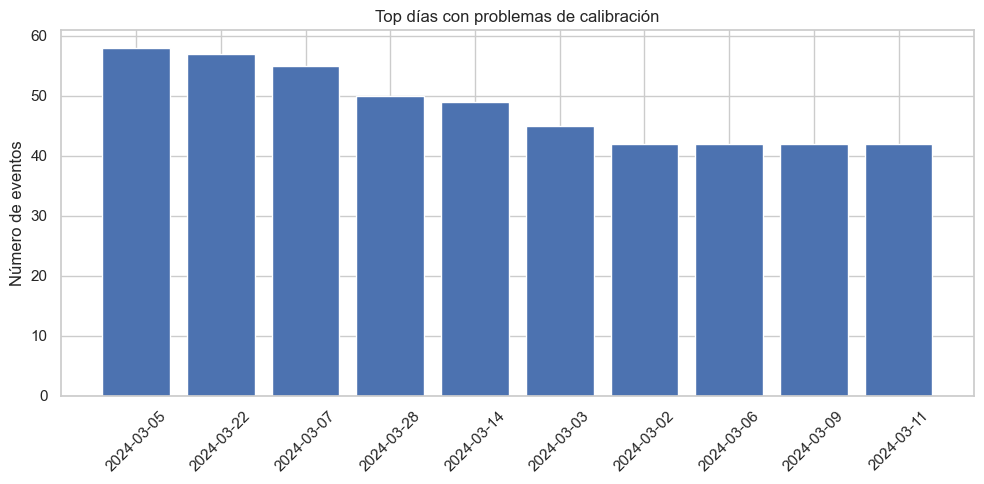

In [97]:
# ===================================================
# VISUALIZACIÓN
# ===================================================

plt.figure(figsize=(10, 5))

plt.bar(
    top_days["DATE"].astype(str),
    top_days["total_issues"]
)

plt.xticks(rotation=45)

plt.title("Top días con problemas de calibración")
plt.ylabel("Número de eventos")

plt.tight_layout()

plt.savefig("../modulo1_diagnostico/outputs/figures/p4_top__problematic_days.png")
plt.show()



## P4 — Evaluación de calibración de earnings

El sistema de earnings no está correctamente calibrado frente a la dinámica del ratio.

Se identifican dos tipos de problemas:

### 1. Sub-reacción
El ratio aumenta, pero los earnings no suben.

### 2. Sobre-gasto
El ratio disminuye o se mantiene bajo, pero los earnings no bajan.

### Resultados clave

Estos problemas no son aislados, sino que se concentran en días específicos:

- 2024-03-05 → 58 eventos (principalmente sub-reacción)
- 2024-03-22 → 57 eventos (dominados por sobre-gasto)
- 2024-03-28 → 50 eventos (alta sub-reacción)

### Conclusión

El sistema de incentivos no responde de forma consistente a la presión operacional.

En algunos momentos reacciona tarde (sub-reacción) y en otros mantiene incentivos innecesarios (sobre-gasto), generando ineficiencias en la operación.

# P5 — ¿Earnings impacta la saturación?

El objetivo es entender si los earnings afectan directamente la saturación operacional.

Se evalúan dos enfoques:

1. Relación directa con el ratio  
2. Relación indirecta a través de la oferta (repartidores)  

Esto permite identificar si earnings es una palanca efectiva y cómo impacta realmente la operación.

In [98]:
# ===================================================
# P5 - RELACIÓN ENTRE EARNINGS Y SATURACIÓN
# ===================================================

# ---------------------------------------------------
# Copia de trabajo
# ---------------------------------------------------
df_p5 = df.copy()


# ---------------------------------------------------
# Variable binaria de lluvia
# ---------------------------------------------------
# útil para segmentar visualmente el comportamiento
df_p5["RAIN"] = (df_p5["PRECIPITATION_MM"] > 0).astype(int)

df_p5["RAIN_LABEL"] = df_p5["RAIN"].map({
    0: "No lluvia",
    1: "Lluvia"
})

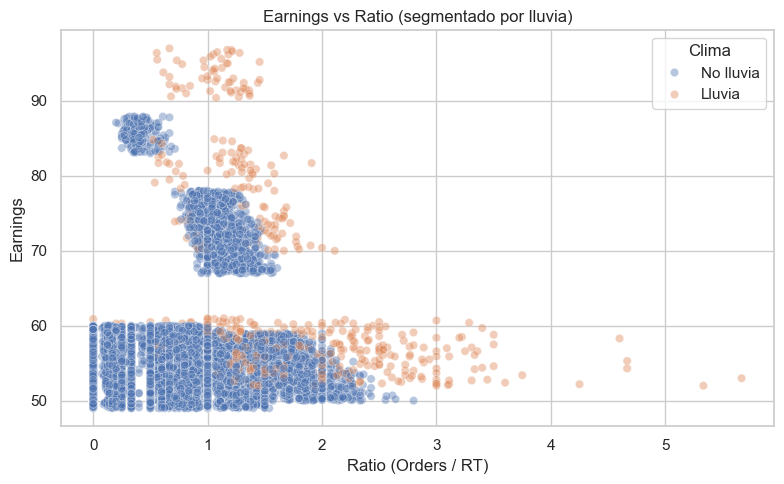

In [99]:
# ===================================================
# RELACIÓN DIRECTA: EARNINGS VS RATIO
# ===================================================

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_p5,
    x="RATIO",
    y="EARNINGS",
    hue="RAIN_LABEL",
    alpha=0.4
)

plt.title("Earnings vs Ratio (segmentado por lluvia)")
plt.xlabel("Ratio (Orders / RT)")
plt.ylabel("Earnings")

plt.legend(title="Clima")

plt.tight_layout()
plt.show()

In [100]:
# ===================================================
# MODELO SOBRE RATIO
# ===================================================

model_ratio = smf.ols(
    "RATIO ~ EARNINGS + PRECIPITATION_MM",
    data=df_p5
).fit()

print(model_ratio.summary())

                            OLS Regression Results                            
Dep. Variable:                  RATIO   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.102
Method:                 Least Squares   F-statistic:                     575.5
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          2.11e-237
Time:                        18:07:08   Log-Likelihood:                -7749.7
No. Observations:               10081   AIC:                         1.551e+04
Df Residuals:                   10078   BIC:                         1.553e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.6721      0.037  

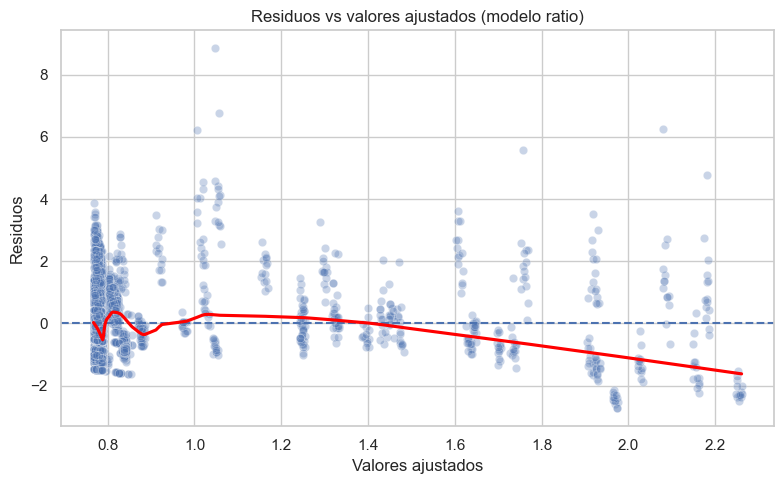

In [101]:
# ===================================================
# DIAGNÓSTICO DEL MODELO (RATIO)
# ===================================================

# residuos y valores ajustados
fitted = model_ratio.fittedvalues

# residuos estudentizados
influence = model_ratio.get_influence()
resid_studentized = influence.resid_studentized_internal


# ---------------------------------------------------
# gráfico residuos vs fitted
# ---------------------------------------------------
plt.figure(figsize=(8, 5))

sns.scatterplot(x=fitted, y=resid_studentized, alpha=0.3)

plt.axhline(0, linestyle="--")

sns.regplot(
    x=fitted,
    y=resid_studentized,
    scatter=False,
    lowess=True,
    color="red"
)

plt.title("Residuos vs valores ajustados (modelo ratio)")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")

plt.tight_layout()
plt.show()

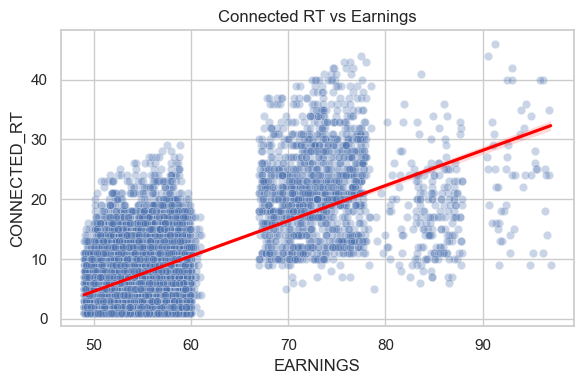

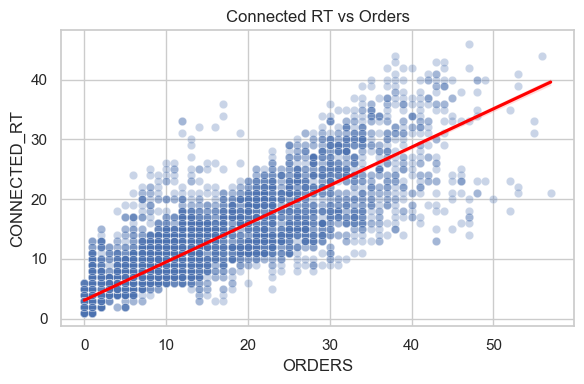

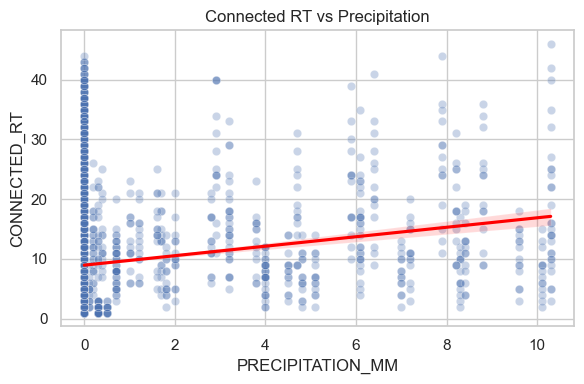

In [102]:
# ===================================================
# RELACIÓN CONECTED_RT VS VARIABLES
# ===================================================

# ---------------------------------------------------
# Earnings vs oferta
# ---------------------------------------------------
plt.figure(figsize=(6, 4))

sns.scatterplot(data=df_p5, x="EARNINGS", y="CONNECTED_RT", alpha=0.3)
sns.regplot(data=df_p5, x="EARNINGS", y="CONNECTED_RT", scatter=False, color="red")

plt.title("Connected RT vs Earnings")
plt.tight_layout()
plt.show()


# ---------------------------------------------------
# Orders vs oferta
# ---------------------------------------------------
plt.figure(figsize=(6, 4))

sns.scatterplot(data=df_p5, x="ORDERS", y="CONNECTED_RT", alpha=0.3)
sns.regplot(data=df_p5, x="ORDERS", y="CONNECTED_RT", scatter=False, color="red")

plt.title("Connected RT vs Orders")
plt.tight_layout()
plt.show()


# ---------------------------------------------------
# Lluvia vs oferta
# ---------------------------------------------------
plt.figure(figsize=(6, 4))

sns.scatterplot(data=df_p5, x="PRECIPITATION_MM", y="CONNECTED_RT", alpha=0.3)
sns.regplot(data=df_p5, x="PRECIPITATION_MM", y="CONNECTED_RT", scatter=False, color="red")

plt.title("Connected RT vs Precipitation")
plt.tight_layout()
plt.show()

In [103]:
# ===================================================
# MODELO DE OFERTA
# ===================================================

model_rt = smf.ols(
    "CONNECTED_RT ~ EARNINGS + ORDERS + PRECIPITATION_MM",
    data=df_p5
).fit()

print(model_rt.summary())

                            OLS Regression Results                            
Dep. Variable:           CONNECTED_RT   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                 2.264e+04
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:07:19   Log-Likelihood:                -24501.
No. Observations:               10081   AIC:                         4.901e+04
Df Residuals:                   10077   BIC:                         4.904e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -12.5830      0.207  

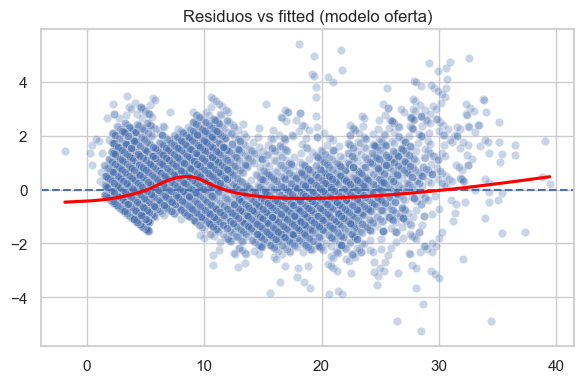

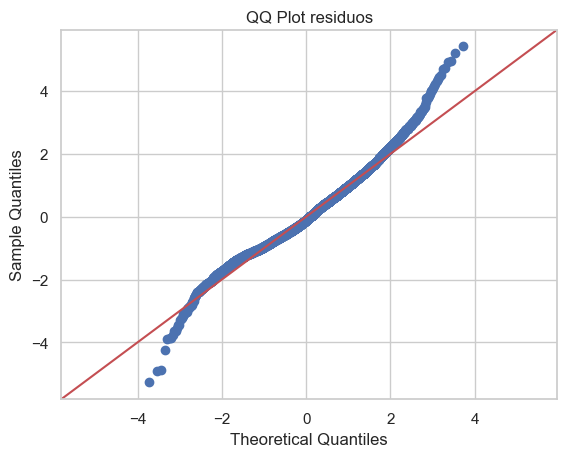

In [104]:
# ===================================================
# DIAGNÓSTICO DEL MODELO DE OFERTA
# ===================================================

fitted = model_rt.fittedvalues

influence = model_rt.get_influence()
resid_studentized = influence.resid_studentized_internal


# residuos vs fitted
plt.figure(figsize=(6, 4))

sns.scatterplot(x=fitted, y=resid_studentized, alpha=0.3)

plt.axhline(0, linestyle="--")

sns.regplot(
    x=fitted,
    y=resid_studentized,
    scatter=False,
    lowess=True,
    color="red"
)

plt.title("Residuos vs fitted (modelo oferta)")
plt.tight_layout()
plt.show()


# QQ plot
sm.qqplot(resid_studentized, line="45")
plt.title("QQ Plot residuos")
plt.show()

## P5 — Relación entre earnings y saturación

### 1. Relación directa (earnings → ratio)

Al analizar la relación directa entre earnings y el ratio, no aparece un patrón claro.

- Hay mucha dispersión en los datos  
- Para niveles similares de earnings, el ratio cambia bastante  
- El poder explicativo es bajo  

---

### 2. Problema del enfoque

El ratio es una variable derivada:

RATIO = ORDERS / CONNECTED_RT

Por lo tanto mezcla:

- Demanda (orders)
- Oferta (repartidores)

y no representa una variable directamente controlable.

---

### 3. Insight clave

Earnings no impacta directamente el ratio.

Su efecto ocurre a través de la oferta (CONNECTED_RT).

---

### 4. Enfoque tomado

En lugar de intentar modelar el ratio, se modela la oferta:

CONNECTED_RT ~ EARNINGS + ORDERS + PRECIPITATION

Aquí sí aparece una relación mucho más clara:

- El modelo tiene buen poder explicativo  
- Earnings tiene un impacto positivo en la cantidad de repartidores  
- La lluvia reduce la disponibilidad

La relación real es encadenada:

EARNINGS → CONNECTED_RT → RATIO

Es decir:

- Earnings mueve la oferta  
- La oferta, junto con la demanda, define el ratio  
- El ratio determina si hay saturación o no  

---

### 5. Conclusión

La relación entre earnings y saturación es indirecta.

- Earnings aumenta la oferta
- La saturación depende del balance entre oferta y demanda.

---

### Idea final

No se debe modelar el ratio directamente.

La forma correcta es modelar la oferta y luego entender cómo impacta la saturación.